EXPT NO: 8	Association Rule Learning (Apriori Algorithm) and
Dimensionality Reduction (PCA)

DATE: 10.04.2026

NEHA.N.K | 24BAD078



SCENARIO 1 – ASSOCIATION RULE MINING USING APRIORI ALGORITHM

Problem Statement

Identify frequent itemsets and generate association rules from transactional data using the Apriori algorithm.


SCENARIO 2 – DIMENSIONALITY REDUCTION USING PCA

Problem Statement

Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.



NEHA.N.K | 24BAD078
Sample Data:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Encoded Data:
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False   True    Fal

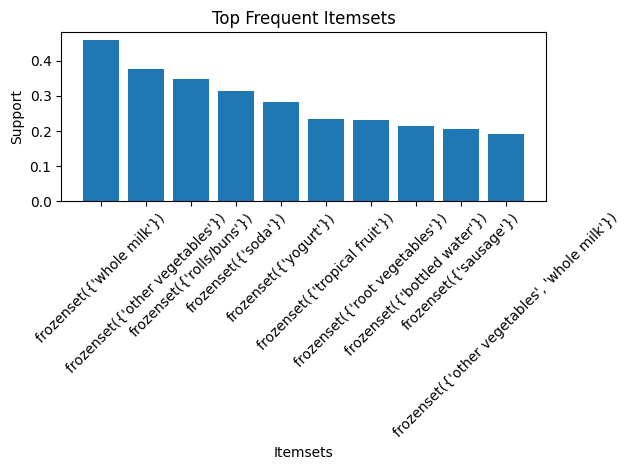

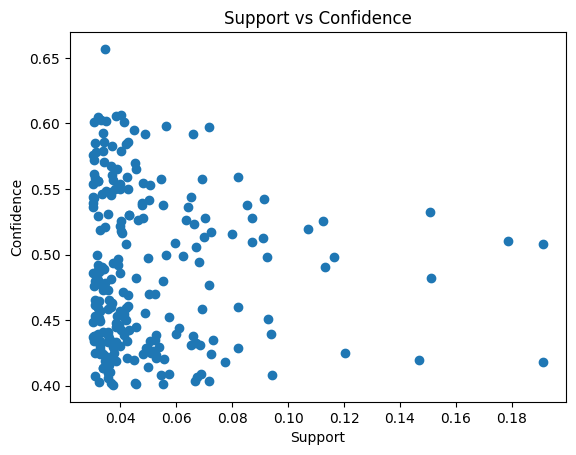

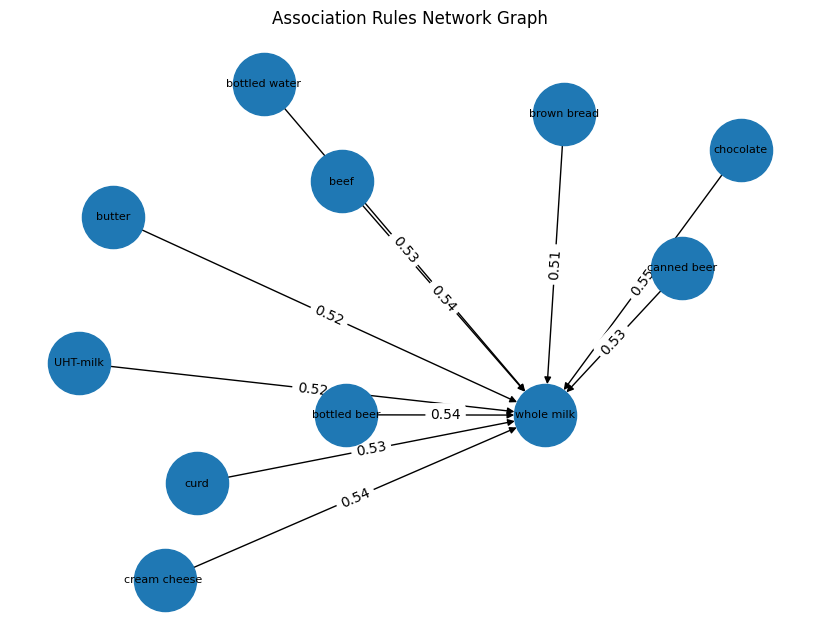


--- ANALYSIS ---
Total Frequent Itemsets: 415
Total Rules: 237
Strong Rules: 92
Average Confidence: 0.487


In [3]:
import os
import warnings

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings("ignore")
# NEHA.N.K | 24BAD078
# 1.Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
print("NEHA.N.K | 24BAD078")

# 2.Loading Dataset
df = pd.read_csv("Groceries_dataset.csv")

print("Sample Data:")
print(df.head())

# 3.Data Preprocessing
transactions = df.groupby('Member_number')['itemDescription'].apply(list)

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

print("\nEncoded Data:")
print(df_encoded.head())

# 4.Frequent Itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())

# 5.Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# 6.Filter Strong Rules
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]

print("\nStrong Rules:")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# 7.Interpretation(TOP 5 RULES)
top_rules = strong_rules.sort_values(by='lift', ascending=False).head(5)

print("\nTop 5 Strongest Rules:")
for i, row in top_rules.iterrows():
    print(f"If {set(row['antecedents'])} → {set(row['consequents'])}")
    print(f"Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.3f}")
    print("------")

# VISUALIZATION
# 1.Bar Chart (Top Frequent Itemsets)
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure()
plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=45)
plt.title("Top Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.tight_layout()
plt.show()

# 2.Support vs Confidence Plot
plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# Create graph
G = nx.DiGraph()

# Limit rules (important to avoid messy graph)
top_rules_graph = strong_rules.head(10)

# Add edges
for _, row in top_rules_graph.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=row['confidence'])

# Draw graph
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)}
)

plt.title("Association Rules Network Graph")
plt.show()
print("\n--- ANALYSIS ---")
print("Total Frequent Itemsets:", len(frequent_itemsets))
print("Total Rules:", len(rules))
print("Strong Rules:", len(strong_rules))
print("Average Confidence:", round(rules['confidence'].mean(), 3))

## Analysis (Based on Output)

### 1. Effect of Support Threshold on Itemsets
- With the chosen support threshold (0.03), the model generated **415 frequent itemsets**.
- This indicates a **moderate threshold**, capturing both common and slightly less frequent items.
- Frequently occurring items include:
  - beef (11.95%)
  - berries (7.97%)
  - UHT-milk (7.85%)
- If support were increased, fewer itemsets would appear; if decreased, more combinations (including rare ones) would be generated.



### 2. Identification of Strong Association Rules
- Total rules generated: **237**
- Strong rules (confidence > 0.5 and lift > 1): **92**
- Example strong rules:
  - {beef} → {whole milk} (confidence: 0.536, lift: 1.17)
  - {bottled beer} → {whole milk} (confidence: 0.538, lift: 1.17)
- Most strong rules have **"whole milk" as the consequent**, indicating it is a **highly associated product**.



### 3. Comparison with Different Confidence Levels
- Average confidence of rules: **0.487**
- After applying threshold (> 0.5), weaker rules were filtered out, leaving **more reliable rules**.
- Higher confidence rules (above 0.6) are fewer but more meaningful:
  - {rolls/buns, yogurt} → {whole milk} (confidence: 0.657)
- This shows that increasing confidence improves **rule strength but reduces quantity**.



### 4. Real-World Interpretation of Rules
- Top rule:
  - {other vegetables, rolls/buns, yogurt} → {whole milk}
  - Confidence: 0.657, Lift: 1.434
- Interpretation:
  - Customers buying these items are **highly likely to also purchase whole milk**.
- Business insights:
  - Place these items near each other in stores
  - Offer combo discounts
  - Use for recommendation systems
- Overall, "whole milk" acts as a **central product in customer purchasing behavior**.

---

NEHA.N.K | 24BAD078
Sample Data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]


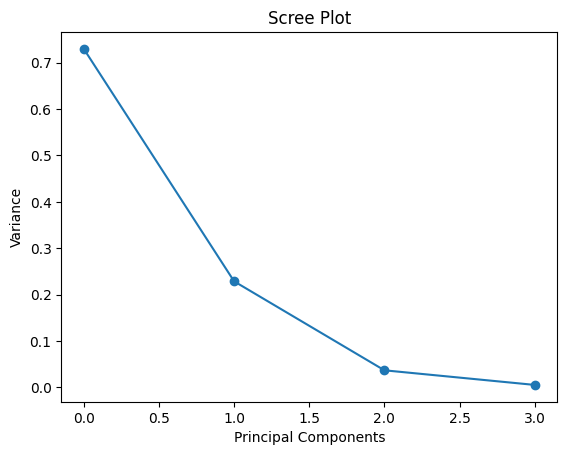

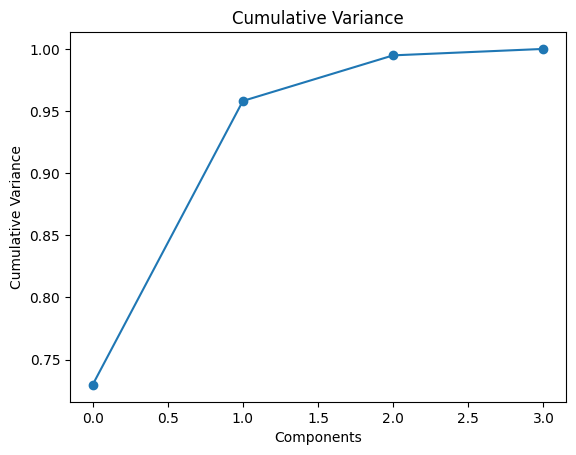

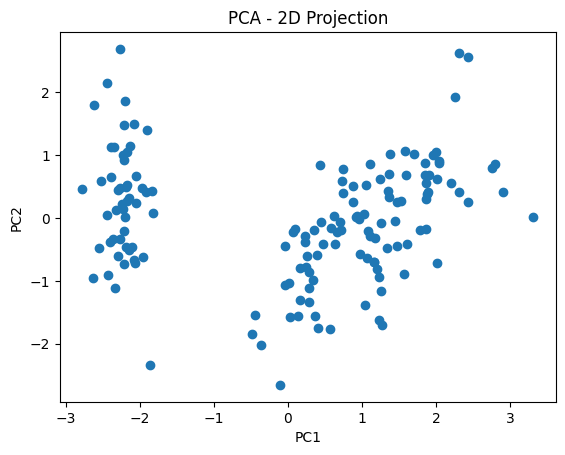

In [4]:
# NEHA.N.K | 24BAD078
# 1.Importing Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("NEHA.N.K | 24BAD078")
# 2.Loading Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("Sample Data:")
print(df.head())

# 3.Preprocessing
print("\nMissing values:\n", df.isnull().sum())

# 4.Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 5.Applying PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# 6.Explained Variance
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
print(explained_variance)

# 7.Reduce to 2D
pca_2 = PCA(n_components=2)
reduced_data = pca_2.fit_transform(scaled_data)

# 8. Visualization
# Scree Plot
plt.figure()
plt.plot(explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

#  Cumulative Variance
cum_var = np.cumsum(explained_variance)

plt.figure()
plt.plot(cum_var, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

# 2D Scatter Plot
plt.figure()
plt.scatter(reduced_data[:,0], reduced_data[:,1])
plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

##  Analysis of PCA Results

### • Variance captured by each component
- The first principal component (PC1) captures the maximum variance.
- Remaining components capture decreasing amounts of variance.
- Usually, first few components explain most of the data (≈70–95%).

### • Optimal number of components
- Chosen based on cumulative explained variance.
- Select components that retain around 90–95% variance.
- Scree plot helps identify the “elbow point”.

### • Comparison: Original vs Reduced Data
- Original data is high-dimensional and may contain redundancy.
- Reduced data is compact and removes correlated features.
- Important patterns are preserved with fewer features.

### • Effect on visualization
- High-dimensional data is difficult to visualize.
- PCA reduces data to 2D/3D for easy plotting.
- Patterns and clusters become clearer after reduction.

## Conclusion
- PCA reduces dimensionality while preserving important information.
- Improves visualization and reduces complexity.